# Exploratory Analysis

This notebook explores the first processed analysis dataset for assessment `34874`. The goal is to understand the distributions and early relationship between last-minute engagement and assessment score before running regression models.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "analysis_assessment_34874.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df.shape

(1658, 22)

## Quick Data Check

In [2]:
df.head()

,id_assessment,id_student,date_submitted,is_banked,score,total_clicks_28d,final_7_clicks,active_learning_days,clicks_days_28_22,clicks_days_21_15,...,cramming_ratio,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,34874,29335,44,0,92.0,1115.0,236.0,22.0,568.0,181.0,...,0.211659,M,West Midlands Region,Lower Than A Level,40-50%,0-35,0,60,N,Distinction
1,34874,29769,54,0,64.0,177.0,19.0,14.0,40.0,41.0,...,0.107345,M,East Midlands Region,A Level or Equivalent,40-50%,0-35,1,60,N,Fail
2,34874,32221,46,0,90.0,367.0,87.0,16.0,128.0,11.0,...,0.237057,M,South Region,A Level or Equivalent,60-70%,0-35,0,60,N,Fail
3,34874,34731,47,0,72.0,339.0,54.0,17.0,17.0,46.0,...,0.159292,M,East Anglian Region,A Level or Equivalent,20-30%,0-35,0,60,N,Withdrawn
4,34874,42616,50,0,74.0,794.0,105.0,22.0,331.0,168.0,...,0.132242,F,Scotland,Lower Than A Level,80-90%,35-55,0,60,N,Pass


In [3]:
summary_cols = [
    "score",
    "total_clicks_28d",
    "final_7_clicks",
    "cramming_ratio",
    "active_learning_days",
]

df[summary_cols].describe().round(3)

,score,total_clicks_28d,final_7_clicks,cramming_ratio,active_learning_days
count,1658.000,1658.000,1658.000,1658.000,1658.000
mean,72.454,473.282,122.777,0.309,14.913
std,16.972,399.007,110.524,0.219,6.929
min,0.000,0.000,0.000,0.000,0.000
25%,64.000,187.000,44.250,0.159,10.000
50%,76.000,387.500,96.500,0.257,15.000
75%,86.000,668.750,168.000,0.405,20.000
max,100.000,3947.000,1196.000,1.000,28.000


## Score Distribution

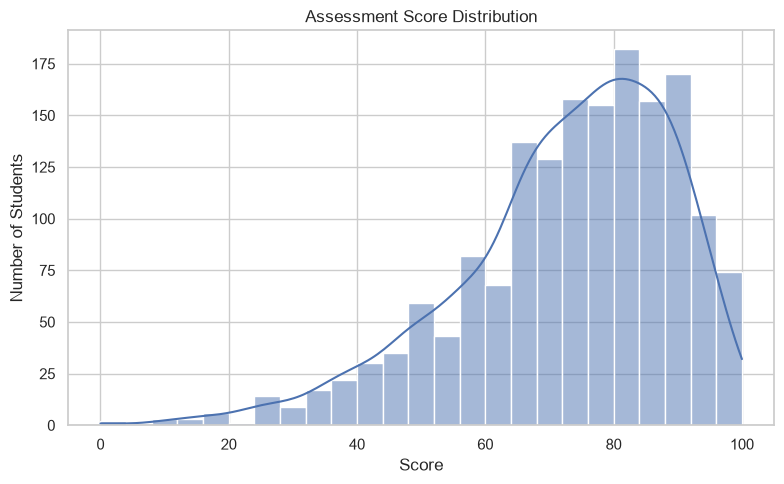

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(df["score"], bins=25, kde=True)
plt.title("Assessment Score Distribution")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "score_distribution.png", dpi=200)
plt.show()

## Cramming Ratio Distribution

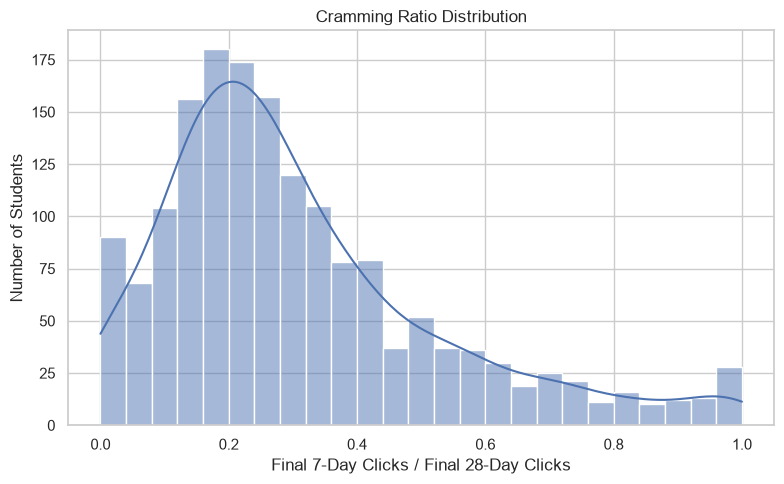

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df["cramming_ratio"], bins=25, kde=True)
plt.title("Cramming Ratio Distribution")
plt.xlabel("Final 7-Day Clicks / Final 28-Day Clicks")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cramming_ratio_distribution.png", dpi=200)
plt.show()

## Score Vs. Cramming Ratio

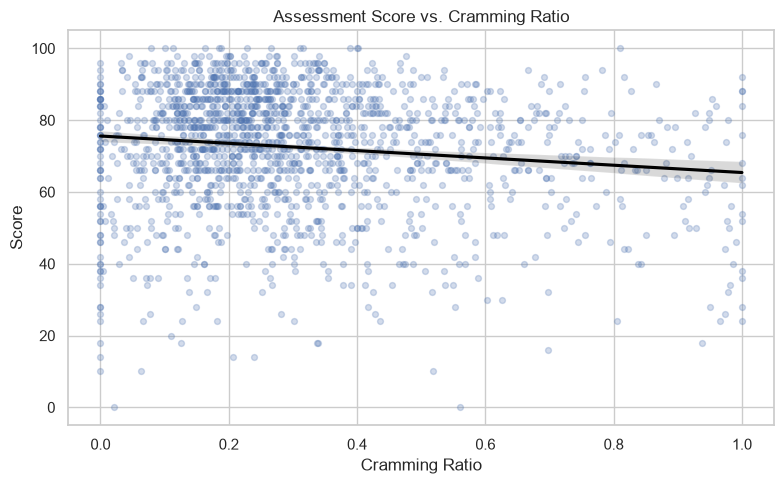

In [6]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x="cramming_ratio",
    y="score",
    scatter_kws={"alpha": 0.25, "s": 18},
    line_kws={"color": "black"},
)
plt.title("Assessment Score vs. Cramming Ratio")
plt.xlabel("Cramming Ratio")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "score_vs_cramming_ratio.png", dpi=200)
plt.show()

## Compare Low, Medium, And High Cramming Students

In [7]:
df["cramming_group"] = pd.qcut(
    df["cramming_ratio"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop",
)

group_summary = (
    df.groupby("cramming_group", observed=False)
    .agg(
        students=("id_student", "count"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
        mean_total_clicks=("total_clicks_28d", "mean"),
        mean_cramming_ratio=("cramming_ratio", "mean"),
    )
    .round(3)
)

group_summary

,students,mean_score,median_score,mean_total_clicks,mean_cramming_ratio
cramming_group,,,,,
Low,553,72.557,76.0,534.872,0.110
Medium,552,75.674,78.0,566.502,0.258
High,553,69.136,72.0,318.642,0.558


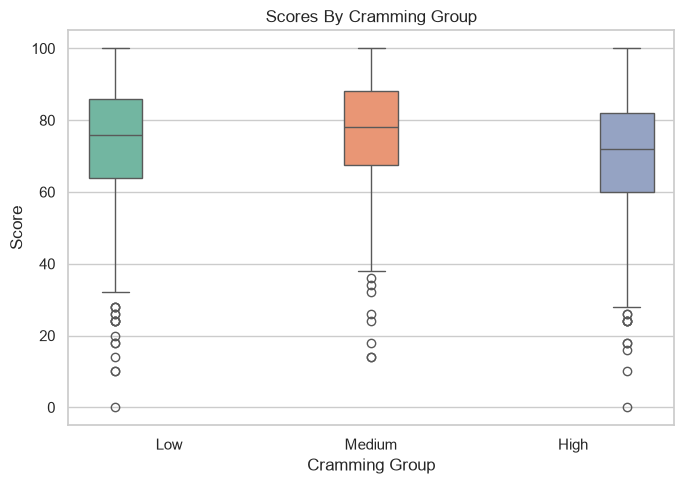

In [8]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="cramming_group", y="score", hue="cramming_group", palette="Set2", legend=False)
plt.title("Scores By Cramming Group")
plt.xlabel("Cramming Group")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "scores_by_cramming_group.png", dpi=200)
plt.show()

## Early Correlations

In [9]:
corr_cols = [
    "score",
    "cramming_ratio",
    "total_clicks_28d",
    "final_7_clicks",
    "active_learning_days",
    "clicks_days_28_22",
    "clicks_days_21_15",
    "clicks_days_14_8",
    "clicks_days_7_1",
]

df[corr_cols].corr()[["score"]].sort_values("score", ascending=False).round(3)

,score
score,1.000
active_learning_days,0.395
total_clicks_28d,0.342
clicks_days_14_8,0.295
clicks_days_28_22,0.290
clicks_days_21_15,0.259
final_7_clicks,0.247
clicks_days_7_1,0.247
cramming_ratio,-0.131
